# LOAD LIBRARIES

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
from datetime import datetime
from scipy.stats import randint, uniform
from sklearn.model_selection import  PredefinedSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet
import os
import sys
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.gapfilling_utils import (
    setup_log_transform,
    undersample_target,
    infer_cv_block_size_from_gaps,
    create_block_splits,
    plot_cv_splits
)

# CONFIGURATION

In [20]:
START_DATE, END_DATE = '2023-11-08', '2024-08-21'
TARGET_FLUX = 'FCH4'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
N_FOLDS = 10
PARCEL_CERTAIN = False # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = False
UNDERSAMPLE = False
ADD_ID = True
ADD_TRT = True

# LOAD DATA

In [21]:
data_main = fluxes = load_parquet(filepath=r"83.1.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()
print(f"\nUsing data from {START_DATE} to {END_DATE}")
TARGET = f"{TARGET_FLUX}_L3.3_CUT_50_QCF0"
print(f"\nTarget column: {TARGET}")

data_main

Loaded .parquet file 83.1.1_GapFillingDataset.parquet (0.277 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 

Using data from 2023-11-08 to 2024-08-21

Target column: FCH4_L3.3_CUT_50_QCF0


,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_50_QCF_gfXGBoost,NEE_L3.3_CUT_50_QCF0_gfXGBoost,RECO_NT_CUT_50_gfXG_QCF0,GPP_NT_CUT_50_gfXG_QCF0,FCH4_L3.3_CUT_16_QCF,FCH4_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_84_QCF,FCH4_L3.3_CUT_16_QCF0,FCH4_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,NaN,2.367268,2.367268,1.568481,-0.798787,-3.231648,-3.231648,-3.231648,-3.231648,-3.231648,-3.231648,B,certain,1.0,...,0.055964,-1.641550,-0.086146,0.576043,0.0,0.0,2.185170,0.986663,29.0,22.0,30.0,22.0,0.300700,5.004348,1032
2023-11-08 00:45:00,NaN,NaN,2.238080,2.238080,1.591144,-0.646936,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,...,0.016644,-2.340741,0.001028,0.291943,0.0,0.0,2.179702,0.983564,29.0,22.0,30.0,22.0,0.300704,5.004376,1033
2023-11-08 01:15:00,NaN,NaN,2.207177,2.207177,1.586392,-0.620786,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,...,0.138010,-0.829823,0.242660,0.618842,0.0,0.0,2.174248,0.980476,29.0,22.0,30.0,22.0,0.300709,5.004405,1034
2023-11-08 01:45:00,NaN,NaN,2.186978,2.186978,1.587581,-0.599397,6.746138,6.746138,6.746138,NaN,NaN,NaN,B,certain,1.0,...,0.307449,-0.724752,0.260016,0.686303,0.0,0.0,2.168807,0.977400,29.0,22.0,30.0,22.0,0.300714,5.004433,1035
2023-11-08 02:15:00,NaN,NaN,2.179536,2.179536,1.584012,-0.595524,3.168362,3.168362,3.168362,3.168362,3.168362,3.168362,B,certain,1.0,...,0.178615,-0.724348,0.032634,0.695635,0.0,0.0,2.163380,0.974334,29.0,22.0,30.0,22.0,0.300718,5.004462,1036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-21 21:45:00,NaN,NaN,4.338262,4.338262,4.553706,0.215444,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,...,-1.707135,0.024579,-0.259299,-0.314632,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14851
2024-08-21 22:15:00,NaN,NaN,4.139963,4.139963,4.508099,0.368136,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,...,-1.744187,0.026603,-0.248552,-0.346094,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14852
2024-08-21 22:45:00,NaN,NaN,4.134058,4.134058,4.478950,0.344892,-6.892062,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,...,-1.720830,0.028865,-0.235925,-0.360680,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14853


# CLEAN DATA

In [22]:
# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Remove data with mixed attribution if PARCEL_CERTAIN==True
if PARCEL_CERTAIN:
    before = len(data)
    data = data.loc[data["parcel_certainty"].eq("certain")].copy()
    print(f"Filtered parcel_certainty=='certain': {len(data)}/{before} rows kept")
else:
    print("Using all data regardless of parcel_certainty (mixed contribution allowed)")

data

Using all data regardless of parcel_certainty (mixed contribution allowed)


,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_50_QCF_gfXGBoost,NEE_L3.3_CUT_50_QCF0_gfXGBoost,RECO_NT_CUT_50_gfXG_QCF0,GPP_NT_CUT_50_gfXG_QCF0,FCH4_L3.3_CUT_16_QCF,FCH4_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_84_QCF,FCH4_L3.3_CUT_16_QCF0,FCH4_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,NaN,2.367268,2.367268,1.568481,-0.798787,-3.231648,-3.231648,-3.231648,-3.231648,-3.231648,-3.231648,B,certain,1.0,...,0.055964,-1.641550,-0.086146,0.576043,0.0,0.0,2.185170,0.986663,29.0,22.0,30.0,22.0,0.300700,5.004348,1032
2023-11-08 02:15:00,NaN,NaN,2.179536,2.179536,1.584012,-0.595524,3.168362,3.168362,3.168362,3.168362,3.168362,3.168362,B,certain,1.0,...,0.178615,-0.724348,0.032634,0.695635,0.0,0.0,2.163380,0.974334,29.0,22.0,30.0,22.0,0.300718,5.004462,1036
2023-11-08 02:45:00,NaN,NaN,1.652604,1.652604,1.580437,-0.072166,8.004995,8.004995,8.004995,8.004995,8.004995,8.004995,B,certain,1.0,...,0.245680,0.083496,0.088045,0.647077,0.0,0.0,2.157967,0.971280,29.0,22.0,30.0,22.0,0.300723,5.004490,1037
2023-11-08 03:15:00,NaN,NaN,1.651816,1.651816,1.570877,-0.080939,-3.270484,-3.270484,-3.270484,-3.270484,-3.270484,-3.270484,B,certain,1.0,...,0.059082,0.121729,0.069218,0.542432,0.0,0.0,2.152567,0.968238,29.0,22.0,30.0,22.0,0.300727,5.004519,1038
2023-11-08 05:15:00,NaN,NaN,1.513415,1.513415,1.557666,0.044251,-12.813660,-12.813660,-12.813660,-12.813660,-12.813660,-12.813660,B,certain,1.0,...,0.018764,0.876177,0.054961,0.979191,0.0,0.0,2.131102,0.956176,29.0,22.0,30.0,22.0,0.300746,5.004635,1042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-20 13:45:00,1.879419,1.879419,1.879419,1.879419,5.046906,3.167487,-6.165051,-6.165051,-6.165051,-6.165051,-6.165051,-6.165051,A,certain,0.0,...,-1.721083,-0.117190,-0.138414,0.034627,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14787
2024-08-20 15:45:00,0.902899,0.902899,0.902899,0.902899,5.212830,4.309931,-8.264321,-8.264321,-8.264321,-8.264321,-8.264321,-8.264321,B,uncertain,1.0,...,-1.626807,-0.192782,-0.247502,-0.107092,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14791
2024-08-21 00:15:00,4.887125,4.887125,4.887125,4.887125,4.970011,0.082886,45.188613,45.188613,45.188613,45.188613,45.188613,45.188613,B,certain,1.0,...,-1.507235,0.153967,-0.062227,-0.147486,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,14808


# SELECT FEATURES

In [23]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
# 'timesince_soil_preparation',
# 'n_decay_timed',
# 'timesince_fert',
# 'wfps_0.05_gfXG_lag9h',
# 'wfps_0.05_gfXG_roll3hmean',
# 'ts_0.3_gfXG_lag6h_roll9hmean',
# 'GPP_U50_f_reddyproc_roll3hsum'
# ]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')

# Drop NAs and keep only selected features
train_mask = data[TARGET].notna() & data[selected_features].notna().all(axis=1)
df_train = data.loc[train_mask, selected_features + [TARGET]].copy()
print(f"\nTraining rows (complete-case): {len(df_train)}/{len(data)}")

X = df_train[selected_features]
y = df_train[TARGET].astype(float)

df_train


The treatment variable (trt) is included in the feature set

Training rows (complete-case): 1545/1552


,GPP_NT_CUT_50_gfXG_QCF0,trt,timesince_prec,wfps_0.05_gfXG,wfps_0.3_gfXG,RECO_NT_CUT_50_gfXG_QCF0_lag3h,ta_lag3h,ts_0.05_gfXG_lag6h,ts_0.15_gfXG_lag3h,wfps_0.05_gfXG_lag3h,wfps_0.05_gfXG_lag6h,wfps_0.05_gfXG_lag9h,wfps_0.3_gfXG_lag6h,wfps_0.3_gfXG_lag9h,NEE_L3.3_CUT_50_QCF_gfXGBoost_roll9hsum,...,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_timed,LAI,can_height,id,FCH4_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 10:15:00,8.884476,1.0,32.0,46.089970,43.419158,1.444111,1.966667,7.059120,8.600102,46.062718,45.843005,45.768440,43.440951,43.003837,0.839284,...,0.246965,-1.202668,1.031801,-0.107977,0.159447,-0.172413,-0.021793,0.369050,0.539389,0.0,29.0,0.300794,5.004930,1052,0.826520
2023-11-08 10:45:00,9.829791,1.0,33.0,46.112539,43.408934,1.449163,2.100000,7.068981,8.564469,46.046153,45.836891,45.851689,43.449641,42.998740,-9.480962,...,0.275648,-0.747932,1.010233,-0.178831,0.145960,-0.260830,-0.040708,0.903538,0.446690,0.0,29.0,0.300799,5.004960,1053,9.740466
2023-11-08 14:15:00,8.049337,1.0,40.0,46.134374,43.561690,1.698781,9.066667,5.714622,9.685588,45.968663,46.123571,45.973385,43.296630,43.440474,-78.278019,...,0.010804,0.246212,0.997085,0.075374,0.125579,0.096674,0.265060,0.590648,0.623283,0.0,29.0,0.300834,5.005174,1060,2.845860
2023-11-09 09:15:00,1.998003,1.0,78.0,43.565013,41.127546,1.378798,0.266667,4.270267,7.197534,43.670328,43.917668,44.500390,42.350081,42.471060,19.541205,...,-0.352656,-1.152182,-2.745121,-0.245556,0.221497,0.408271,-1.222534,-1.346920,-2.075754,0.0,29.0,0.301035,5.006412,1098,6.635354
2023-11-09 14:15:00,1.256899,1.0,88.0,44.186853,42.656713,1.685196,8.666667,4.062401,7.053717,43.477570,43.620468,43.573012,41.800084,42.109163,-25.721082,...,0.566385,0.079600,-1.947521,-0.144982,-0.465814,0.135988,0.856629,-0.182160,-0.904977,0.0,29.0,0.301091,5.006760,1108,-14.870929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-20 13:45:00,3.167487,0.0,63.0,35.665226,42.913925,4.802366,17.500000,19.280000,20.271481,35.990856,35.963289,36.075027,43.031115,43.049156,34.896220,...,-0.298063,-0.486618,-1.591825,-0.458726,-0.740482,-1.721083,-0.117190,-0.138414,0.034627,0.0,0.0,0.000000,0.000000,14787,-6.165051
2024-08-20 15:45:00,4.309931,1.0,67.0,35.081670,42.810731,4.937935,19.420000,19.922962,20.525556,35.857960,36.013607,35.979360,43.003512,43.036184,21.231776,...,-0.931937,-1.018078,-1.999897,-0.426068,-0.760300,-1.626807,-0.192782,-0.247502,-0.107092,0.0,0.0,0.000000,0.000000,14791,-8.264321
2024-08-21 00:15:00,0.082886,1.0,84.0,33.542140,42.904943,4.882690,18.660000,23.989629,22.048148,33.852742,34.284384,35.266471,42.750976,42.863230,71.164331,...,-0.742244,-2.381714,-2.675015,-0.318737,-0.733296,-1.507235,0.153967,-0.062227,-0.147486,0.0,0.0,0.000000,0.000000,14808,45.188613


# IMBALANCE HANDLING

## UNDER SAMPLING

In [24]:
if UNDERSAMPLE:
    df_train2, cutoff_value = undersample_target(
        df_train, TARGET,
        quantile_cutoff=0.8,
        fraction=0.5,
        random_state=42,
        verbose=True,
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
else:
    print("Undersampling not applied.")

Undersampling not applied.


## LOG TRANSFORMATION

In [25]:
if LOG_TRANSFORM:
    log_fn, inv_fn, min_value, df_train2 = setup_log_transform(
        df_train, TARGET, apply=True, plot=True, bins=20
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
    print(f"Applied log1p transform (shift={min_value if min_value < 0 else 0.0:.4g}).")
else:
    inv_fn = None
    print("Log transform not applied.")

Log transform not applied.


# CROSS-VAL SPLITS

Requested split=0.10; n_folds=10; achieved test fractions ~ 0.091–0.109


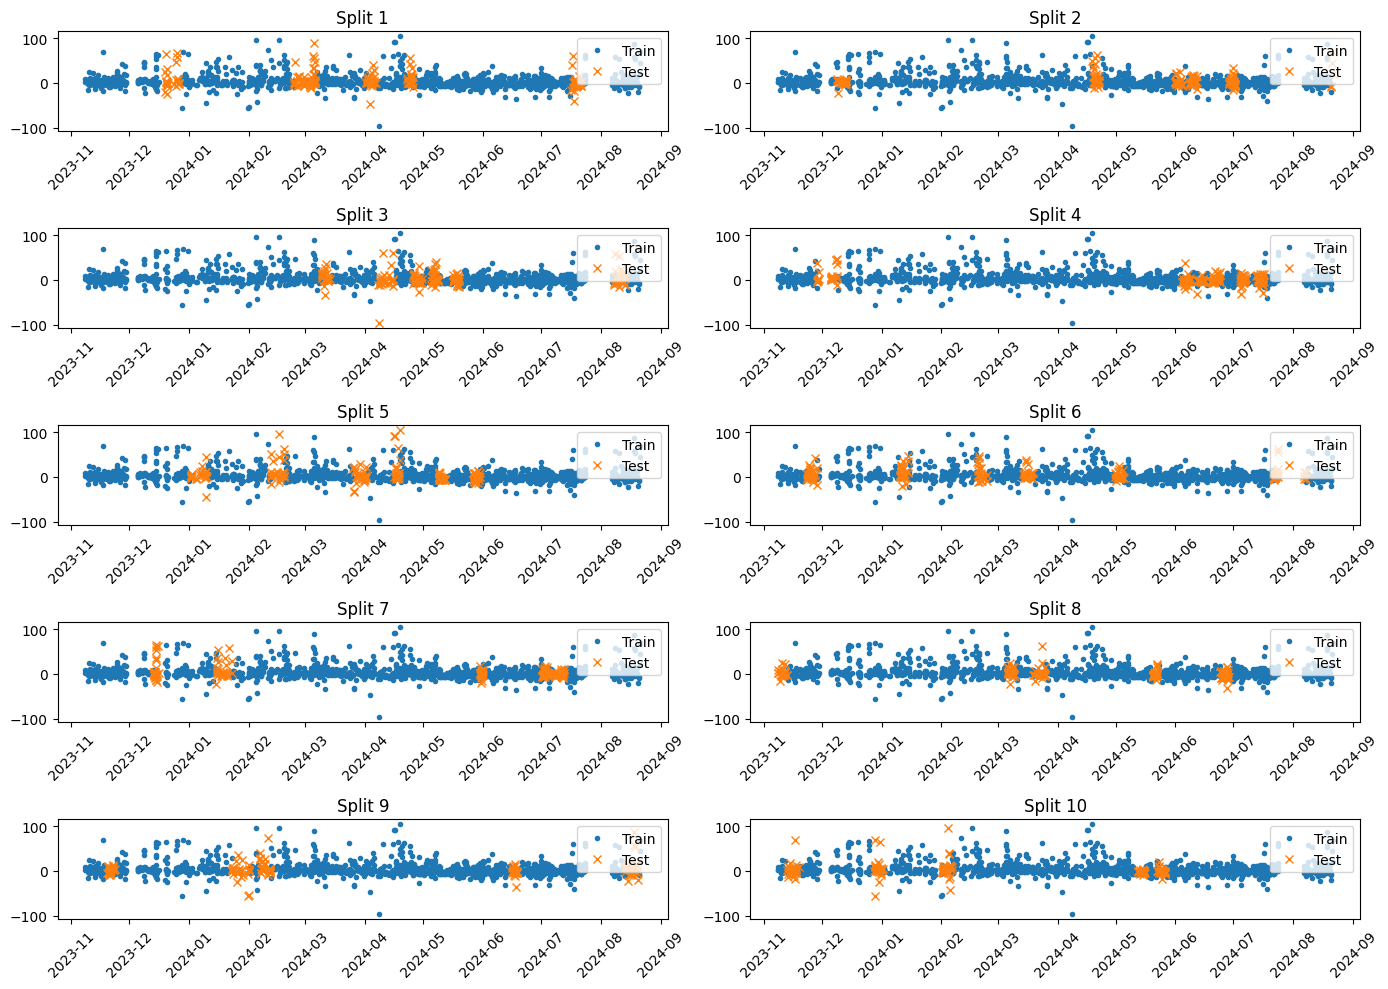

In [ ]:
# Time-block cross-validation splits
# Block size is inferred from gaps in the target variable
block_size = infer_cv_block_size_from_gaps(data_main[TARGET], quantile=0.9, fallback=6)
print(f"\nUsing block size of {block_size} time steps for CV splits.\n")
split_frac = 1.0 / float(N_FOLDS)
splits = create_block_splits(
    X,
    split=split_frac,
    block_size=block_size,
    random_state=42,
    shuffle_blocks=True,
    verbose=True,
)

# optional diagnostic plot
plot_cv_splits(X, y, splits, ncols=2);


# HYPERPARAMETER TUNING

In [27]:
# Convert custom CV splits to PredefinedSplit for Scikit-Learn
test_fold = np.full(len(X), -1)  # Initialize with -1 (all as training)
for fold_idx, (train_idx, test_idx) in enumerate(splits):
    test_fold[test_idx] = fold_idx  # Assign test samples to a specific fold
ps = PredefinedSplit(test_fold)

# DEFINE RANGES
if MODEL_TYPE == 'XGBoost':
    # XGBoost: Use continuous distributions for fine-tuning
    PARAM_DIST = {
        'n_estimators': randint(100, 1000),      # Any integer 100-1000
        'max_depth': randint(3, 15),             # Any integer 3-15
        'learning_rate': uniform(0.005, 0.1),    # Any float 0.005-0.105
        'subsample': uniform(0.6, 0.4),          # 0.6 to 1.0
        'colsample_bytree': uniform(0.6, 0.4),   # 0.6 to 1.0
        'min_child_weight': randint(1, 10),
        'gamma': uniform(0, 0.5)
    }
    model = XGBRegressor(n_jobs=-1, random_state=42)

elif MODEL_TYPE == 'RandomForest':
    # RF: Integers for counts/depths
    PARAM_DIST = {
        'n_estimators': randint(100, 500),
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', 1.0]
    }
    model = RandomForestRegressor(n_jobs=-1, random_state=42)

# RUN RANDOM SEARCH
print(f"Starting optimization for {MODEL_TYPE}...")

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=PARAM_DIST,
    n_iter=50,       # 50 random tries
    cv=ps,           # Uses your exact time-blocks
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
search.fit(X, y)

# RESULTS
print(f"Best RMSE: {-search.best_score_:.4f}")
print("Best Params:", search.best_params_)

Starting optimization for XGBoost...
Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best RMSE: 14.6309
Best Params: {'colsample_bytree': np.float64(0.9290402242638633), 'gamma': np.float64(0.18009532070563145), 'learning_rate': np.float64(0.01770605126518848), 'max_depth': 3, 'min_child_weight': 8, 'n_estimators': 152, 'subsample': np.float64(0.7086171663278967)}


# EXPORT 

In [28]:
filename = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(filename, "w") as f:
    json.dump(search.best_params_, f)

# **End of notebook**

In [29]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-01-22 14:39:02
